# Lecture 1: Neural Networks Fundamentals

## Week 8: From MLPs to CNNs

---

### What You'll Learn Today

1. **What are Neural Networks?** - The basic idea
2. **Tensors** - The data structure of deep learning
3. **The Artificial Neuron** - Building block of neural networks
4. **Activation Functions** - Adding non-linearity
5. **Introduction to PyTorch** - Our deep learning framework

---

### Why Neural Networks?

In previous weeks, we learned about:
- Linear models (Week 2)
- Decision trees and ensembles (Week 3)

**Neural Networks can:**
- Learn complex, non-linear patterns automatically
- Work with images, text, audio, and more
- Scale to massive datasets

Let's understand how they work!

---

## Part 1: What is a Neural Network?

### The Biological Inspiration

Neural networks are loosely inspired by how neurons work in our brains:

```
BIOLOGICAL NEURON          ARTIFICIAL NEURON
                           
Dendrites (inputs)    -->  Input values (x1, x2, ...)
Cell body (processing) --> Weighted sum + bias
Axon (output)         -->  Activation function output
```

### The Key Idea

A neural network is just **layers of connected neurons** that transform inputs into outputs:

```
INPUT        HIDDEN         OUTPUT
LAYER        LAYER(S)       LAYER

 x1 ----\                  
         \----> h1 ----\
 x2 ------>     h2 ------> y
         /----> h3 ----/
 x3 ----/
```

**That's it!** The magic is in how we train these connections (weights).

---

## Part 2: Tensors - The Language of Deep Learning

Before we build neural networks, we need to understand **tensors**.

### What is a Tensor?

A tensor is simply a **multi-dimensional array**:

```
TENSOR DIMENSIONS

0D Tensor (Scalar):     5                    # Just a number
1D Tensor (Vector):     [1, 2, 3]            # A list of numbers
2D Tensor (Matrix):     [[1, 2], [3, 4]]     # A table of numbers
3D Tensor:              [[[1,2], [3,4]],     # A cube of numbers
                         [[5,6], [7,8]]]     # (e.g., color image)
```

### Why Tensors Matter

- **Images** are 3D tensors: (height, width, channels)
- **Batches of images** are 4D tensors: (batch, height, width, channels)
- **Video** is 5D: (batch, time, height, width, channels)

Let's see this in code!

In [59]:
# First, let's import PyTorch
import torch
import numpy as np

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("MPS available:", torch.mps.is_available())

if torch.mps.is_available():
    mps_device = torch.device("mps")

PyTorch version: 2.9.1
GPU available: False
MPS available: True


In [60]:
# Creating tensors

# 0D Tensor (Scalar)
scalar = torch.tensor(5)
print("Scalar:", scalar)
print("Shape:", scalar.shape)
print("Dimensions:", scalar.ndim)
print()

Scalar: tensor(5)
Shape: torch.Size([])
Dimensions: 0



In [61]:
# 1D Tensor (Vector)
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print("Vector:", vector)
print("Shape:", vector.shape)
print("Dimensions:", vector.ndim)
print()

Vector: tensor([1., 2., 3., 4.])
Shape: torch.Size([4])
Dimensions: 1



In [62]:
# 2D Tensor (Matrix)
matrix = torch.tensor([[1, 2, 3],
                       [4, 5, 6]])
print("Matrix:")
print(matrix)
print("Shape:", matrix.shape)  # 2 rows, 3 columns
print("Dimensions:", matrix.ndim)
print()

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Dimensions: 2



In [63]:
# 3D Tensor (like a color image: height x width x channels)
# Let's create a tiny 2x2 RGB image
image = torch.tensor([[[255, 0, 0],    # Red pixel
                       [0, 255, 0]],   # Green pixel
                      [[0, 0, 255],    # Blue pixel
                       [255, 255, 0]]]) # Yellow pixel
print("Image tensor:")
print(image)
print("Shape:", image.shape)  # (2, 2, 3) = height, width, RGB channels
print("Dimensions:", image.ndim)

Image tensor:
tensor([[[255,   0,   0],
         [  0, 255,   0]],

        [[  0,   0, 255],
         [255, 255,   0]]])
Shape: torch.Size([2, 2, 3])
Dimensions: 3


### Common Tensor Operations

Neural networks are built on tensor operations:

In [64]:
# Basic operations
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Addition:       ", a + b)
print("Multiplication: ", a * b)  # Element-wise
print("Dot product:    ", torch.dot(a, b))  # 1*4 + 2*5 + 3*6 = 32

Addition:        tensor([5., 7., 9.])
Multiplication:  tensor([ 4., 10., 18.])
Dot product:     tensor(32.)


In [65]:
# Matrix multiplication - THE most important operation!
# This is how neural networks transform data

X = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])  # 3x2 matrix (3 samples, 2 features)

W = torch.tensor([[0.1, 0.2, 0.3],
                  [0.4, 0.5, 0.6]])  # 2x3 matrix (weights: 2 inputs -> 3 outputs)

# Matrix multiplication: (3x2) @ (2x3) = (3x3)
output = X @ W  # or torch.matmul(X, W)
print("Input shape:", X.shape)
print("Weights shape:", W.shape)
print("Output shape:", output.shape)
print("\nOutput:")
print(output)

Input shape: torch.Size([3, 2])
Weights shape: torch.Size([2, 3])
Output shape: torch.Size([3, 3])

Output:
tensor([[0.9000, 1.2000, 1.5000],
        [1.9000, 2.6000, 3.3000],
        [2.9000, 4.0000, 5.1000]])


### Visual: Matrix Multiplication in Neural Networks

```
INPUT (3 samples, 2 features)     WEIGHTS (2 inputs, 3 neurons)     OUTPUT (3 samples, 3 neurons)

    [1, 2]                            [0.1, 0.2, 0.3]                    [0.9, 1.2, 1.5]
    [3, 4]           @                [0.4, 0.5, 0.6]         =          [1.9, 2.6, 3.3]
    [5, 6]                                                               [2.9, 4.0, 5.1]

Each row of output = one sample transformed by all neurons
```

This is exactly what happens in a neural network layer!

---

## Part 3: The Artificial Neuron

### A Single Neuron

One neuron performs a simple computation:

```
       x1 ---(w1)---\
                     \
       x2 ---(w2)-----> SUM + b --> Activation --> output
                     /
       x3 ---(w3)---/

output = activation(w1*x1 + w2*x2 + w3*x3 + b)
       = activation(W @ X + b)
```

**Components:**
- **Inputs (x):** The data
- **Weights (w):** Learnable parameters (how important each input is)
- **Bias (b):** Learnable offset
- **Activation:** Non-linear function (we'll discuss soon)

Let's implement a single neuron:

In [66]:
# A single neuron from scratch

def single_neuron(inputs, weights, bias):
    """
    Computes: output = sum(inputs * weights) + bias
    """
    weighted_sum = torch.dot(inputs, weights) + bias
    return weighted_sum

# Example: 3 inputs
inputs = torch.tensor([1.0, 2.0, 3.0])  # Feature values
weights = torch.tensor([0.5, -0.2, 0.1])  # How important each feature is
bias = torch.tensor(0.3)  # Offset

output = single_neuron(inputs, weights, bias)
print(f"Inputs: {inputs.tolist()}")
print(f"Weights: {weights.tolist()}")
print(f"Bias: {bias.item()}")
print(f"\nOutput: {output.item():.4f}")
print(f"\nCalculation: (1.0*0.5) + (2.0*-0.2) + (3.0*0.1) + 0.3 = {output.item():.4f}")

Inputs: [1.0, 2.0, 3.0]
Weights: [0.5, -0.20000000298023224, 0.10000000149011612]
Bias: 0.30000001192092896

Output: 0.7000

Calculation: (1.0*0.5) + (2.0*-0.2) + (3.0*0.1) + 0.3 = 0.7000


### From One Neuron to a Layer

A **layer** is just multiple neurons processing the same inputs:

```
         Neuron 1: W1 @ X + b1 --> output1
INPUT -->Neuron 2: W2 @ X + b2 --> output2  --> [output1, output2, output3]
         Neuron 3: W3 @ X + b3 --> output3
```

With matrix operations, this becomes: `Output = X @ W + b`

In [67]:
# A layer with 3 neurons (3 inputs -> 3 outputs)

def neural_layer(inputs, weights, bias):
    """
    One layer of neurons.
    inputs: (batch_size, n_inputs)
    weights: (n_inputs, n_neurons)
    bias: (n_neurons,)
    """
    return inputs @ weights + bias

# 2 samples, 3 features each
inputs = torch.tensor([[1.0, 2.0, 3.0],
                       [4.0, 5.0, 6.0]])

# Weights: 3 inputs -> 4 neurons
weights = torch.tensor([[0.1, 0.2, -0.1, 0.3],
                        [0.4, -0.3, 0.2, 0.1],
                        [-0.2, 0.1, 0.3, -0.2]])

# One bias per neuron
bias = torch.tensor([0.1, -0.1, 0.2, 0.0])

output = neural_layer(inputs, weights, bias)
print("Input shape:", inputs.shape)    # (2 samples, 3 features)
print("Weights shape:", weights.shape)  # (3 inputs, 4 neurons)
print("Bias shape:", bias.shape)        # (4 neurons)
print("Output shape:", output.shape)    # (2 samples, 4 outputs)
print("\nOutput:")
print(output)

Input shape: torch.Size([2, 3])
Weights shape: torch.Size([3, 4])
Bias shape: torch.Size([4])
Output shape: torch.Size([2, 4])

Output:
tensor([[ 0.4000, -0.2000,  1.4000, -0.1000],
        [ 1.3000, -0.2000,  2.6000,  0.5000]])


---

## Part 4: Activation Functions

### Why Do We Need Activation Functions?

Without activation functions, neural networks can only learn **linear relationships**!

```
Layer 1: Y1 = X @ W1 + b1      (linear)
Layer 2: Y2 = Y1 @ W2 + b2     (linear)

Combined: Y2 = (X @ W1 + b1) @ W2 + b2
            = X @ (W1 @ W2) + (b1 @ W2 + b2)
            = X @ W_combined + b_combined   (still linear!)
```

**Activation functions add non-linearity**, allowing networks to learn complex patterns!

### Common Activation Functions

```
1. SIGMOID: Squashes output to (0, 1)
   f(x) = 1 / (1 + e^(-x))
   Use: Output layer for binary classification

2. TANH: Squashes output to (-1, 1)
   f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
   Use: Sometimes in hidden layers

3. ReLU: Rectified Linear Unit (MOST POPULAR!)
   f(x) = max(0, x)
   Use: Hidden layers (default choice)

4. SOFTMAX: Converts to probability distribution
   f(x_i) = e^(x_i) / sum(e^(x_j))
   Use: Output layer for multi-class classification
```

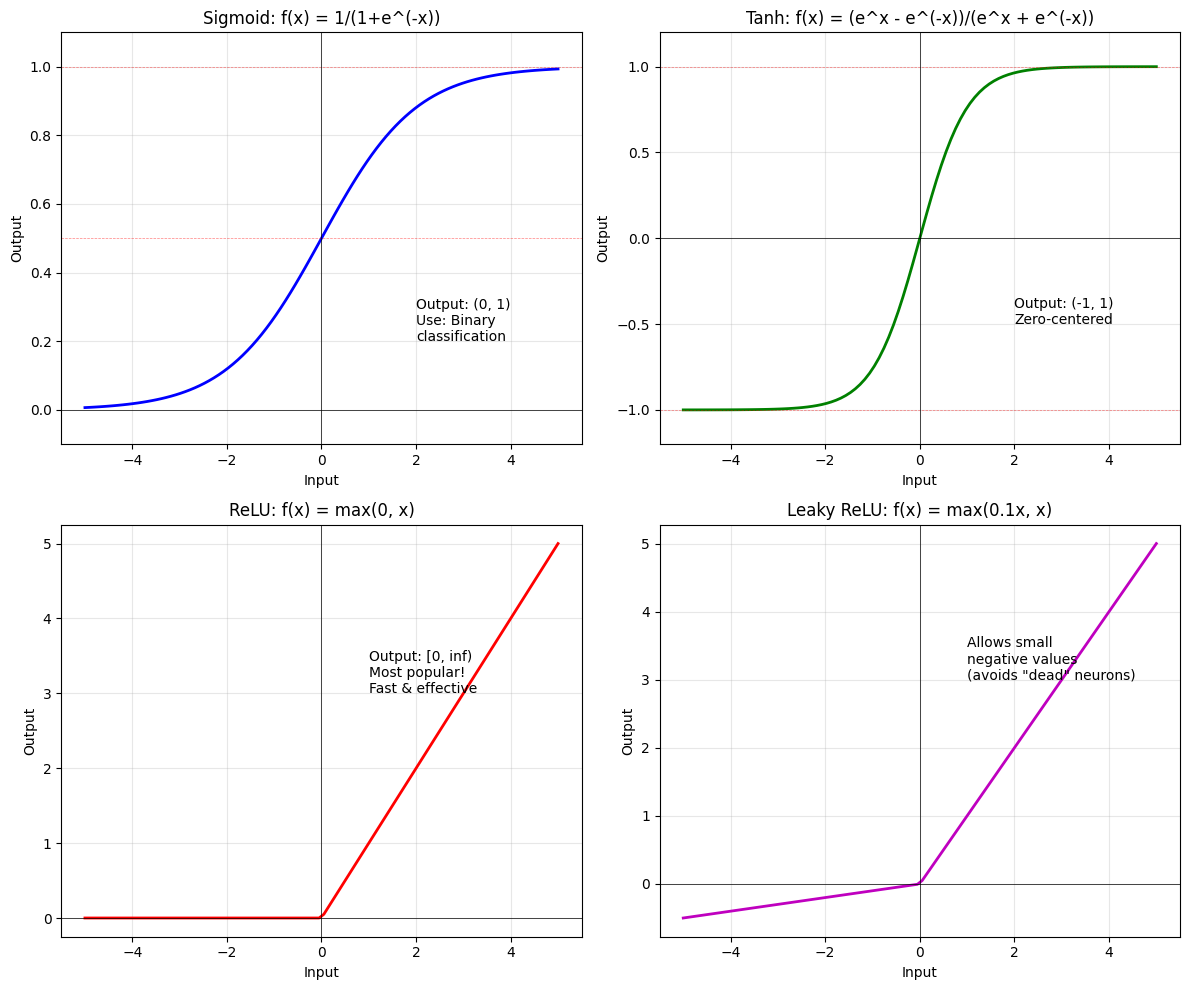

In [68]:
import matplotlib.pyplot as plt

# Let's visualize activation functions
x = torch.linspace(-5, 5, 100)

# Define activation functions
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = torch.relu(x)
leaky_relu = torch.nn.functional.leaky_relu(x, negative_slope=0.1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sigmoid
axes[0, 0].plot(x.numpy(), sigmoid.numpy(), 'b-', linewidth=2)
axes[0, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 0].axhline(y=0.5, color='r', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0, 0].axhline(y=1, color='r', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0, 0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 0].set_title('Sigmoid: f(x) = 1/(1+e^(-x))', fontsize=12)
axes[0, 0].set_xlabel('Input')
axes[0, 0].set_ylabel('Output')
axes[0, 0].set_ylim(-0.1, 1.1)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(2, 0.2, 'Output: (0, 1)\nUse: Binary\nclassification', fontsize=10)

# Tanh
axes[0, 1].plot(x.numpy(), tanh.numpy(), 'g-', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 1].axhline(y=-1, color='r', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0, 1].axhline(y=1, color='r', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0, 1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 1].set_title('Tanh: f(x) = (e^x - e^(-x))/(e^x + e^(-x))', fontsize=12)
axes[0, 1].set_xlabel('Input')
axes[0, 1].set_ylabel('Output')
axes[0, 1].set_ylim(-1.2, 1.2)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(2, -0.5, 'Output: (-1, 1)\nZero-centered', fontsize=10)

# ReLU
axes[1, 0].plot(x.numpy(), relu.numpy(), 'r-', linewidth=2)
axes[1, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].set_title('ReLU: f(x) = max(0, x)', fontsize=12)
axes[1, 0].set_xlabel('Input')
axes[1, 0].set_ylabel('Output')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(1, 3, 'Output: [0, inf)\nMost popular!\nFast & effective', fontsize=10)

# Leaky ReLU
axes[1, 1].plot(x.numpy(), leaky_relu.numpy(), 'm-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].set_title('Leaky ReLU: f(x) = max(0.1x, x)', fontsize=12)
axes[1, 1].set_xlabel('Input')
axes[1, 1].set_ylabel('Output')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(1, 3, 'Allows small\nnegative values\n(avoids "dead" neurons)', fontsize=10)

plt.tight_layout()
plt.show()

In [69]:
# Let's see how ReLU works numerically
values = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print("Input values:", values.tolist())
print("After ReLU:  ", torch.relu(values).tolist())
print()
print("ReLU is simple: negative values become 0, positive values stay the same!")

Input values: [-2.0, -1.0, 0.0, 1.0, 2.0]
After ReLU:   [0.0, 0.0, 0.0, 1.0, 2.0]

ReLU is simple: negative values become 0, positive values stay the same!


In [70]:
# Softmax for multi-class classification
# Converts raw scores (logits) to probabilities

logits = torch.tensor([2.0, 1.0, 0.1])  # Raw network output for 3 classes
probabilities = torch.softmax(logits, dim=0)

print("Raw scores (logits):", logits.tolist())
print("After Softmax:      ", [f"{p:.4f}" for p in probabilities.tolist()])
print("Sum of probabilities:", probabilities.sum().item())
print()
print("Softmax converts scores to probabilities that sum to 1!")
print(f"Predicted class: {torch.argmax(probabilities).item()} (with {probabilities.max().item():.1%} confidence)")

Raw scores (logits): [2.0, 1.0, 0.10000000149011612]
After Softmax:       ['0.6590', '0.2424', '0.0986']
Sum of probabilities: 1.0000001192092896

Softmax converts scores to probabilities that sum to 1!
Predicted class: 0 (with 65.9% confidence)


---

## Part 5: Building a Simple Neural Network with PyTorch

Now let's put it all together and build a neural network using PyTorch!

In [71]:
import torch.nn as nn

# Method 1: Using nn.Sequential (Simple!)
# A network with: 4 inputs -> 8 hidden neurons -> 3 outputs

simple_network = nn.Sequential(
    nn.Linear(4, 8),    # Layer 1: 4 inputs -> 8 outputs
    nn.ReLU(),          # Activation
    nn.Linear(8, 3)     # Layer 2: 8 inputs -> 3 outputs
)

print("Simple Neural Network:")
print(simple_network)
print("\nTotal parameters:", sum(p.numel() for p in simple_network.parameters()))

Simple Neural Network:
Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)

Total parameters: 67


In [72]:
# Let's trace through the network

# Create a sample input (1 sample, 4 features)
sample_input = torch.tensor([[1.0, 2.0, 3.0, 4.0]])

# Pass through the network
output = simple_network(sample_input)

print("Input shape: ", sample_input.shape)
print("Output shape:", output.shape)
print("\nInput: ", sample_input.tolist())
print("Output:", output.tolist())

Input shape:  torch.Size([1, 4])
Output shape: torch.Size([1, 3])

Input:  [[1.0, 2.0, 3.0, 4.0]]
Output: [[-0.2904086709022522, 0.07212579250335693, 0.187214195728302]]


In [73]:
# Method 2: Using a class (More flexible!)

class MyNeuralNetwork(nn.Module):
    """
    A simple neural network for classification.
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        # Define layers
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """
        Forward pass: how data flows through the network.
        """
        x = self.layer1(x)       # Linear transformation
        x = self.activation(x)   # Non-linearity
        x = self.layer2(x)       # Output layer
        return x

# Create network
network = MyNeuralNetwork(input_size=4, hidden_size=8, output_size=3)
print("Custom Neural Network:")
print(network)

Custom Neural Network:
MyNeuralNetwork(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=8, out_features=3, bias=True)
)


In [74]:
# Let's look at the weights!

print("Layer 1 weights shape:", network.layer1.weight.shape)  # (8 neurons, 4 inputs)
print("Layer 1 bias shape:   ", network.layer1.bias.shape)    # (8 neurons)
print()
print("Layer 2 weights shape:", network.layer2.weight.shape)  # (3 neurons, 8 inputs)
print("Layer 2 bias shape:   ", network.layer2.bias.shape)    # (3 neurons)
print()
print("First 3 weights of Layer 1:")
print(network.layer1.weight[:3].data)

Layer 1 weights shape: torch.Size([8, 4])
Layer 1 bias shape:    torch.Size([8])

Layer 2 weights shape: torch.Size([3, 8])
Layer 2 bias shape:    torch.Size([3])

First 3 weights of Layer 1:
tensor([[ 0.3403,  0.1371,  0.4131,  0.3671],
        [-0.1273,  0.4395, -0.1758,  0.4204],
        [ 0.1446,  0.2807, -0.4763, -0.3403]])


---

## Part 6: Understanding the Data Flow

Let's visualize what happens when data passes through our network:

In [75]:
# Step-by-step forward pass

# Input: 1 sample with 4 features
x = torch.tensor([[1.0, 2.0, 3.0, 4.0]])
print("Step 0 - Input:")
print(f"  Shape: {x.shape}")
print(f"  Values: {x.tolist()}")
print()

# Step 1: Linear layer 1
z1 = network.layer1(x)
print("Step 1 - After Linear Layer 1 (before activation):")
print(f"  Shape: {z1.shape}")
print(f"  Values: {[f'{v:.3f}' for v in z1[0].tolist()]}")
print()

# Step 2: ReLU activation
a1 = network.activation(z1)
print("Step 2 - After ReLU Activation:")
print(f"  Shape: {a1.shape}")
print(f"  Values: {[f'{v:.3f}' for v in a1[0].tolist()]}")
print("  (Notice: negative values became 0!)")
print()

# Step 3: Linear layer 2 (output)
output = network.layer2(a1)
print("Step 3 - After Linear Layer 2 (Output):")
print(f"  Shape: {output.shape}")
print(f"  Values: {[f'{v:.3f}' for v in output[0].tolist()]}")
print()

# Convert to probabilities
probs = torch.softmax(output, dim=1)
print("Final - After Softmax (Probabilities):")
print(f"  Values: {[f'{v:.3f}' for v in probs[0].tolist()]}")
print(f"  Predicted class: {torch.argmax(probs, dim=1).item()}")

Step 0 - Input:
  Shape: torch.Size([1, 4])
  Values: [[1.0, 2.0, 3.0, 4.0]]

Step 1 - After Linear Layer 1 (before activation):
  Shape: torch.Size([1, 8])
  Values: ['3.608', '2.327', '-1.953', '0.762', '-2.936', '1.699', '2.141', '0.144']

Step 2 - After ReLU Activation:
  Shape: torch.Size([1, 8])
  Values: ['3.608', '2.327', '0.000', '0.762', '0.000', '1.699', '2.141', '0.144']
  (Notice: negative values became 0!)

Step 3 - After Linear Layer 2 (Output):
  Shape: torch.Size([1, 3])
  Values: ['0.847', '-0.915', '-0.248']

Final - After Softmax (Probabilities):
  Values: ['0.664', '0.114', '0.222']
  Predicted class: 0


---

## Summary

### What We Learned Today:

1. **Neural Networks** are layers of connected neurons

2. **Tensors** are multi-dimensional arrays - the data structure of deep learning
   - 0D: Scalar, 1D: Vector, 2D: Matrix, 3D+: Higher-dimensional arrays

3. **A Neuron** computes: `output = activation(weights @ inputs + bias)`

4. **Activation Functions** add non-linearity:
   - **ReLU**: Most popular for hidden layers
   - **Sigmoid**: Binary classification output
   - **Softmax**: Multi-class classification output

5. **PyTorch** makes building neural networks easy with `nn.Module`

### Key Formulas:

```
Single Neuron:  y = activation(w @ x + b)
Layer:          Y = activation(X @ W + b)
ReLU:           f(x) = max(0, x)
Sigmoid:        f(x) = 1 / (1 + e^(-x))
Softmax:        f(x_i) = e^(x_i) / sum(e^(x_j))
```

### Next Lecture:
We'll learn **how neural networks learn** - Backpropagation and Training!

---

## Exercises

Try these to test your understanding:

1. Create a tensor representing a batch of 5 grayscale images (28x28 pixels each)
2. Build a neural network with 2 hidden layers (input: 10, hidden1: 20, hidden2: 15, output: 5)
3. Apply different activation functions to the same input and compare the outputs

In [76]:
# Exercise 1: Create a batch of 5 grayscale images (28x28)
# Your code here:

batch_images = torch.randn(5, 28, 28)  # (batch, height, width)
print("Batch shape:", batch_images.shape)

Batch shape: torch.Size([5, 28, 28])


In [77]:
# Exercise 2: Build a network with 2 hidden layers
# Your code here:

two_hidden_network = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 15),
    nn.ReLU(),
    nn.Linear(15, 5)
)
print(two_hidden_network)

Sequential(
  (0): Linear(in_features=10, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=15, bias=True)
  (3): ReLU()
  (4): Linear(in_features=15, out_features=5, bias=True)
)


In [78]:
# Exercise 3: Compare activation functions
# Your code here:

x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("Input:   ", x.tolist())
print("ReLU:    ", torch.relu(x).tolist())
print("Sigmoid: ", [f"{v:.3f}" for v in torch.sigmoid(x).tolist()])
print("Tanh:    ", [f"{v:.3f}" for v in torch.tanh(x).tolist()])

Input:    [-2.0, -1.0, 0.0, 1.0, 2.0]
ReLU:     [0.0, 0.0, 0.0, 1.0, 2.0]
Sigmoid:  ['0.119', '0.269', '0.500', '0.731', '0.881']
Tanh:     ['-0.964', '-0.762', '0.000', '0.762', '0.964']
